In [65]:
import kagglehub
path = kagglehub.dataset_download("prachi13/customer-analytics")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\Girija S.H\.cache\kagglehub\datasets\prachi13\customer-analytics\versions\1


In [66]:
import os
path = r"C:\Users\Girija S.H\.cache\kagglehub\datasets\prachi13\customer-analytics\versions\1"
print(os.listdir(path))


['Train.csv']


In [67]:
import pandas as pd
import os
path = r"C:\Users\Girija S.H\.cache\kagglehub\datasets\prachi13\customer-analytics\versions\1"
train_path = os.path.join(path, "Train.csv")
df = pd.read_csv(train_path)
df.head()


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [68]:
print(df.shape)      
print(df.info())     
print(df.describe())

(10999, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   10999 non-null  int64 
 1   Warehouse_block      10999 non-null  object
 2   Mode_of_Shipment     10999 non-null  object
 3   Customer_care_calls  10999 non-null  int64 
 4   Customer_rating      10999 non-null  int64 
 5   Cost_of_the_Product  10999 non-null  int64 
 6   Prior_purchases      10999 non-null  int64 
 7   Product_importance   10999 non-null  object
 8   Gender               10999 non-null  object
 9   Discount_offered     10999 non-null  int64 
 10  Weight_in_gms        10999 non-null  int64 
 11  Reached.on.Time_Y.N  10999 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.0+ MB
None
                ID  Customer_care_calls  Customer_rating  Cost_of_the_Product  \
count  10999.00000         10999.000000     10999.000000 

In [5]:
"""ONE
Which shipment mode has the highest average cost of products?"""
df.groupby("Mode_of_Shipment")["Cost_of_the_Product"].mean().sort_values(ascending=False).max()


210.47556818181818

In [6]:
"""TWO
Among delayed shipments, what percentage belong to each product importance level?"""
df[df["Reached.on.Time_Y.N"]==1]["Product_importance"].value_counts(normalize=True)*100



low       47.843974
medium    42.770075
high       9.385952
Name: Product_importance, dtype: float64

In [7]:
"""THREE
Discout greated than 50 and product importance is high"""
df[(df["Discount_offered"] > 50) & (df["Product_importance"]=="high")]


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
36,37,D,Ship,3,5,137,4,high,F,62,1477,1
108,109,D,Ship,4,5,238,3,high,F,55,3257,1
116,117,A,Road,4,1,150,4,high,M,60,1024,1
140,141,A,Flight,4,4,264,3,high,M,59,2020,1
158,159,A,Ship,5,5,205,2,high,M,65,3671,1
...,...,...,...,...,...,...,...,...,...,...,...,...
2915,2916,F,Ship,3,4,242,3,high,M,54,3011,1
2938,2939,C,Ship,4,5,156,5,high,F,55,1619,1
3017,3018,F,Flight,4,1,235,2,high,M,64,2107,1
3028,3029,C,Flight,5,2,172,4,high,F,61,1161,1


In [8]:
"""FOUR
Create a new column that classifies shipments as "Premium" if cost > 250 and importance = "high", else "Standard"."""
df["Category"] = df.apply(lambda x: "Premium" if (x["Cost_of_the_Product"]>250 and x["Product_importance"]=="high") else "Standard", axis=1)


In [9]:
df.head(5)


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,Category
0,1,D,Flight,4,2,177,3,low,F,44,1233,1,Standard
1,2,F,Flight,4,5,216,2,low,M,59,3088,1,Standard
2,3,A,Flight,2,2,183,4,low,M,48,3374,1,Standard
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1,Standard
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1,Standard


In [10]:
"""FIVE
Among Ship and Road shipments, check how many were delayed."""
df[df["Mode_of_Shipment"].isin(["Ship","Road"])]["Reached.on.Time_Y.N"].value_counts()


1    5494
0    3728
Name: Reached.on.Time_Y.N, dtype: int64

In [11]:
"""SIX
Get the 3 cheapest products with their weights."""
df.nsmallest(3, "Cost_of_the_Product")[["Cost_of_the_Product","Weight_in_gms"]]


,Cost_of_the_Product,Weight_in_gms
431,96,1294
974,96,1655
2418,96,1186


In [12]:
"""SEVEN
Categorize discounts into Low (0–20), Medium (21–50), High (51+)."""
df["Discount_Category"] = pd.cut(df["Discount_offered"], bins=[0,20,50,100], labels=["Low","Medium","High"])


In [13]:
df.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,Category,Discount_Category
0,1,D,Flight,4,2,177,3,low,F,44,1233,1,Standard,Medium
1,2,F,Flight,4,5,216,2,low,M,59,3088,1,Standard,High
2,3,A,Flight,2,2,183,4,low,M,48,3374,1,Standard,Medium
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1,Standard,Low
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1,Standard,Medium


In [14]:
"""EIGHT
.Convert "low","medium","high" to numbers 1,2,3"""
df["Product_importance_num"] = df["Product_importance"].replace({"low":1,"medium":2,"high":3})


In [15]:
df.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,Category,Discount_Category,Product_importance_num
0,1,D,Flight,4,2,177,3,low,F,44,1233,1,Standard,Medium,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1,Standard,High,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1,Standard,Medium,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1,Standard,Low,2
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1,Standard,Medium,2


In [16]:
"""NINE
Convert Reached.on.Time_Y.N into text labels "On Time" and "Delayed"""
df["Delivery_Status"] = df["Reached.on.Time_Y.N"].map({0:"On Time", 1:"Delayed"})


In [17]:
df.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,Category,Discount_Category,Product_importance_num,Delivery_Status
0,1,D,Flight,4,2,177,3,low,F,44,1233,1,Standard,Medium,1,Delayed
1,2,F,Flight,4,5,216,2,low,M,59,3088,1,Standard,High,1,Delayed
2,3,A,Flight,2,2,183,4,low,M,48,3374,1,Standard,Medium,1,Delayed
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1,Standard,Low,2,Delayed
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1,Standard,Medium,2,Delayed


In [18]:
"""TEN
Convert "low", "medium", "high" into numeric values for modeling."""
mapping = {"low": 1, "medium": 2, "high": 3}
df["Product_importance_num"] = df["Product_importance"].map(mapping).astype("int")


#EDA (EXPLORTARY DATA ANALYSIS)

In [20]:
import pandas as pd
import numpy as np

# Separate numerical & categorical columns
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()


In [21]:
# Descriptive stats for numerical features
desc_stats = df[num_cols].describe().T
print(desc_stats)

                       count         mean          std     min     25%  \
ID                   10999.0  5500.000000  3175.282140     1.0  2750.5   
Customer_care_calls  10999.0     4.054459     1.141490     2.0     3.0   
Customer_rating      10999.0     2.990545     1.413603     1.0     2.0   
Cost_of_the_Product  10999.0   210.196836    48.063272    96.0   169.0   
Prior_purchases      10999.0     3.567597     1.522860     2.0     3.0   
Discount_offered     10999.0    13.373216    16.205527     1.0     4.0   
Weight_in_gms        10999.0  3634.016729  1635.377251  1001.0  1839.5   
Reached.on.Time_Y.N  10999.0     0.596691     0.490584     0.0     0.0   

                        50%     75%      max  
ID                   5500.0  8249.5  10999.0  
Customer_care_calls     4.0     5.0      7.0  
Customer_rating         3.0     4.0      5.0  
Cost_of_the_Product   214.0   251.0    310.0  
Prior_purchases         3.0     4.0     10.0  
Discount_offered        7.0    10.0     65.0  
Weig

In [22]:
# Add Median
desc_stats["median"] = df[num_cols].median()
print(desc_stats)

                       count         mean          std     min     25%  \
ID                   10999.0  5500.000000  3175.282140     1.0  2750.5   
Customer_care_calls  10999.0     4.054459     1.141490     2.0     3.0   
Customer_rating      10999.0     2.990545     1.413603     1.0     2.0   
Cost_of_the_Product  10999.0   210.196836    48.063272    96.0   169.0   
Prior_purchases      10999.0     3.567597     1.522860     2.0     3.0   
Discount_offered     10999.0    13.373216    16.205527     1.0     4.0   
Weight_in_gms        10999.0  3634.016729  1635.377251  1001.0  1839.5   
Reached.on.Time_Y.N  10999.0     0.596691     0.490584     0.0     0.0   

                        50%     75%      max  median  
ID                   5500.0  8249.5  10999.0  5500.0  
Customer_care_calls     4.0     5.0      7.0     4.0  
Customer_rating         3.0     4.0      5.0     3.0  
Cost_of_the_Product   214.0   251.0    310.0   214.0  
Prior_purchases         3.0     4.0     10.0     3.0  
Dis

In [23]:
# Add Variance & Coefficient of Variation (CV)
desc_stats["variance"] = df[num_cols].var()
desc_stats["cv"] = desc_stats["std"] / desc_stats["mean"]
print(desc_stats)

                       count         mean          std     min     25%  \
ID                   10999.0  5500.000000  3175.282140     1.0  2750.5   
Customer_care_calls  10999.0     4.054459     1.141490     2.0     3.0   
Customer_rating      10999.0     2.990545     1.413603     1.0     2.0   
Cost_of_the_Product  10999.0   210.196836    48.063272    96.0   169.0   
Prior_purchases      10999.0     3.567597     1.522860     2.0     3.0   
Discount_offered     10999.0    13.373216    16.205527     1.0     4.0   
Weight_in_gms        10999.0  3634.016729  1635.377251  1001.0  1839.5   
Reached.on.Time_Y.N  10999.0     0.596691     0.490584     0.0     0.0   

                        50%     75%      max  median      variance        cv  
ID                   5500.0  8249.5  10999.0  5500.0  1.008242e+07  0.577324  
Customer_care_calls     4.0     5.0      7.0     4.0  1.302999e+00  0.281539  
Customer_rating         3.0     4.0      5.0     3.0  1.998274e+00  0.472691  
Cost_of_the_Produ

In [24]:
# Add Skewness & Kurtosis
desc_stats["skewness"] = df[num_cols].skew()
desc_stats["kurtosis"] = df[num_cols].kurt()
print(desc_stats)

                       count         mean          std     min     25%  \
ID                   10999.0  5500.000000  3175.282140     1.0  2750.5   
Customer_care_calls  10999.0     4.054459     1.141490     2.0     3.0   
Customer_rating      10999.0     2.990545     1.413603     1.0     2.0   
Cost_of_the_Product  10999.0   210.196836    48.063272    96.0   169.0   
Prior_purchases      10999.0     3.567597     1.522860     2.0     3.0   
Discount_offered     10999.0    13.373216    16.205527     1.0     4.0   
Weight_in_gms        10999.0  3634.016729  1635.377251  1001.0  1839.5   
Reached.on.Time_Y.N  10999.0     0.596691     0.490584     0.0     0.0   

                        50%     75%      max  median      variance        cv  \
ID                   5500.0  8249.5  10999.0  5500.0  1.008242e+07  0.577324   
Customer_care_calls     4.0     5.0      7.0     4.0  1.302999e+00  0.281539   
Customer_rating         3.0     4.0      5.0     3.0  1.998274e+00  0.472691   
Cost_of_the_P

In [25]:
# Value counts for categorical features
for col in cat_cols:
    print(f"\n🔹 Value counts for {col}:")
    print(df[col].value_counts())


🔹 Value counts for Warehouse_block:
F    3666
D    1834
A    1833
B    1833
C    1833
Name: Warehouse_block, dtype: int64

🔹 Value counts for Mode_of_Shipment:
Ship      7462
Flight    1777
Road      1760
Name: Mode_of_Shipment, dtype: int64

🔹 Value counts for Product_importance:
low       5297
medium    4754
high       948
Name: Product_importance, dtype: int64

🔹 Value counts for Gender:
F    5545
M    5454
Name: Gender, dtype: int64

🔹 Value counts for Category:
Standard    10796
Premium       203
Name: Category, dtype: int64

🔹 Value counts for Delivery_Status:
Delayed    6563
On Time    4436
Name: Delivery_Status, dtype: int64


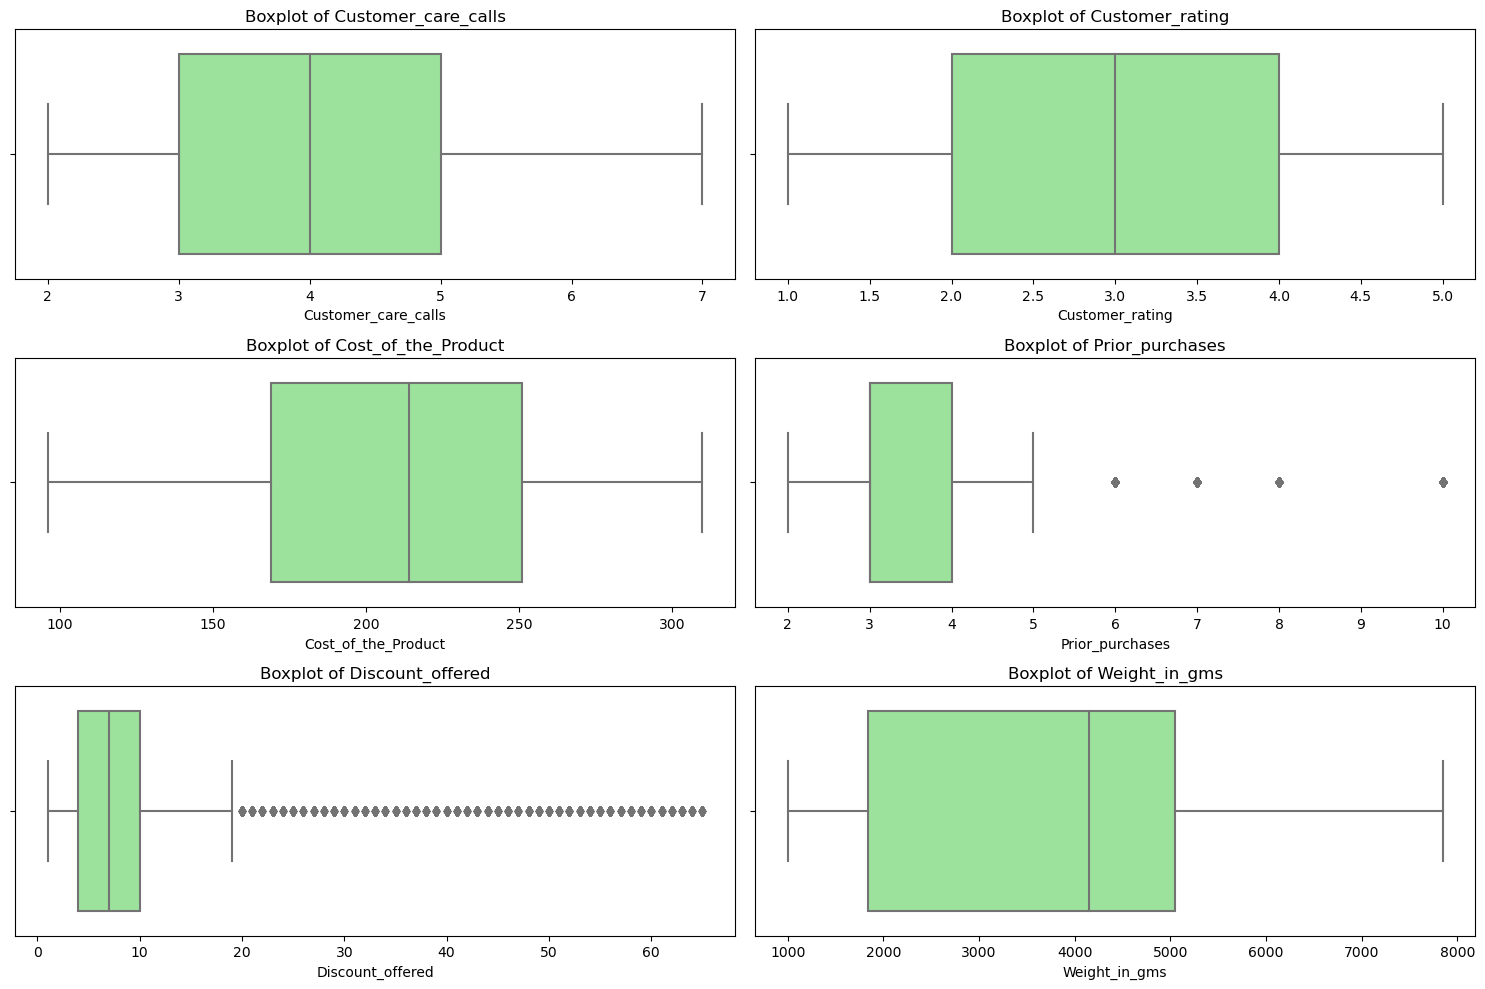

In [27]:
"""Boxplots are used in univariate and bivariate analysis to visualize the spread of numerical data 
and detect outliers. They show the median, quartiles (Q1 & Q3), interquartile range (IQR), and 
potential outliers as points outside the whiskers. This helps us quickly identify variables with 
extreme values that may need treatment in preprocessing."""
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['Customer_care_calls','Customer_rating',
            'Cost_of_the_Product','Prior_purchases',
            'Discount_offered','Weight_in_gms']

plt.figure(figsize=(15,10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3,2,i)
    sns.boxplot(x=df[col], color="lightgreen")
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

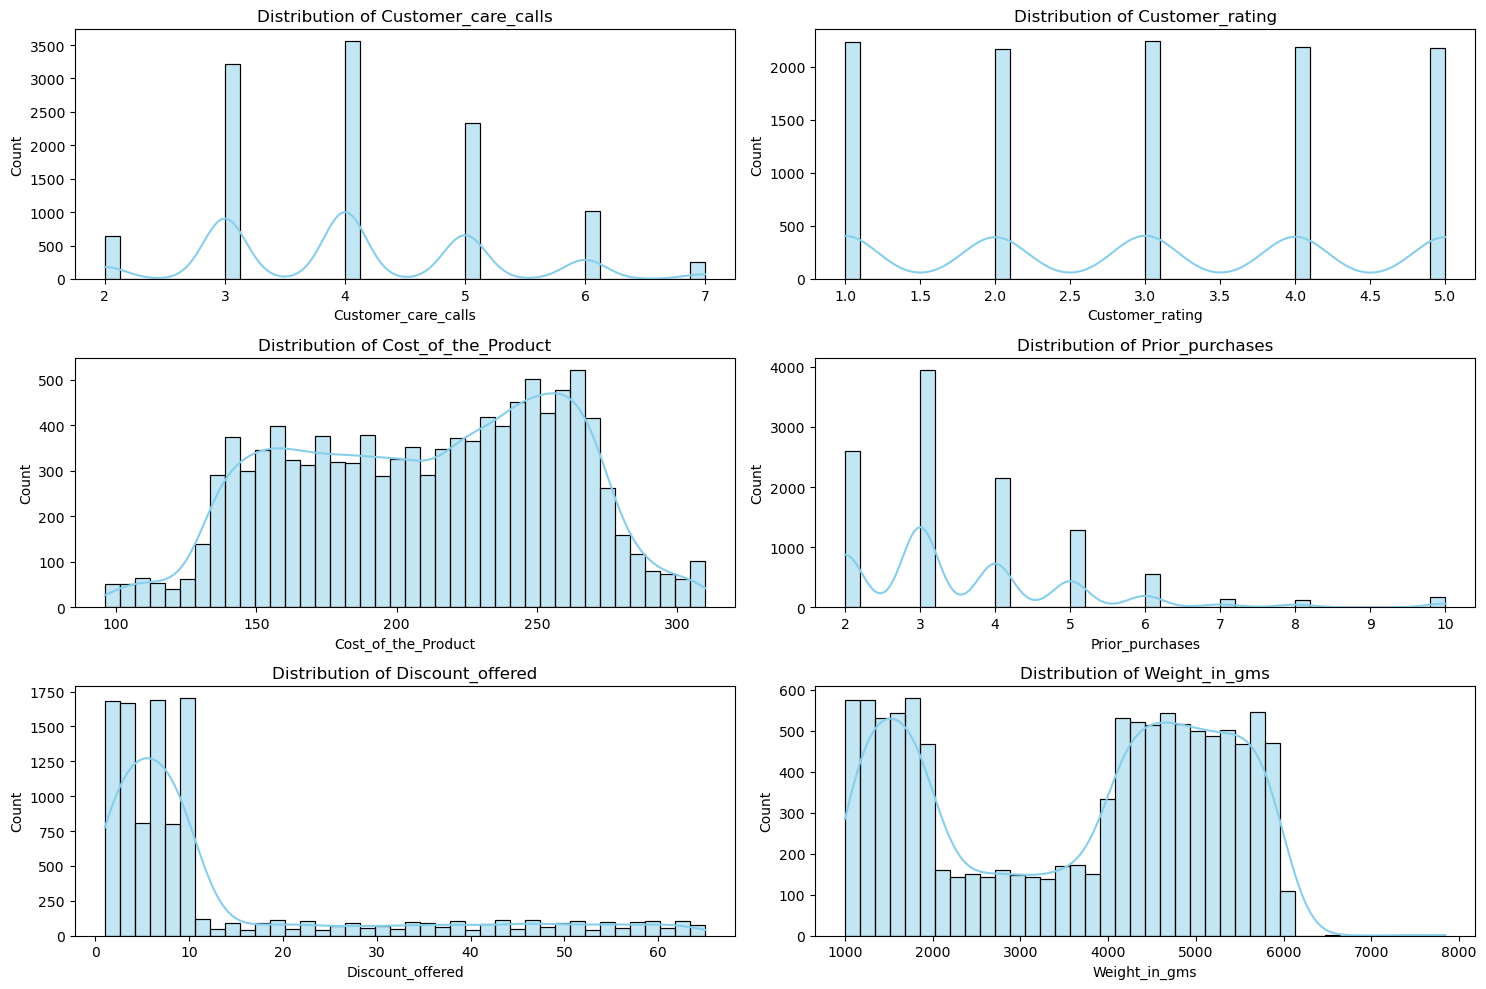

In [28]:
"""Histograms are used to study the frequency distribution of numerical variables. They help us 
understand the shape of the data (normal, skewed, uniform), detect skewness, and identify the
concentration of values. Adding a KDE (Kernel Density Estimate) curve provides a smooth estimate of 
the probability distribution, making it easier to see whether the variable is symmetric or skewed."""
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['Customer_care_calls','Customer_rating',
            'Cost_of_the_Product','Prior_purchases',
            'Discount_offered','Weight_in_gms']

plt.figure(figsize=(15,10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3,2,i)
    sns.histplot(df[col], bins=40, kde=True, color="skyblue")
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

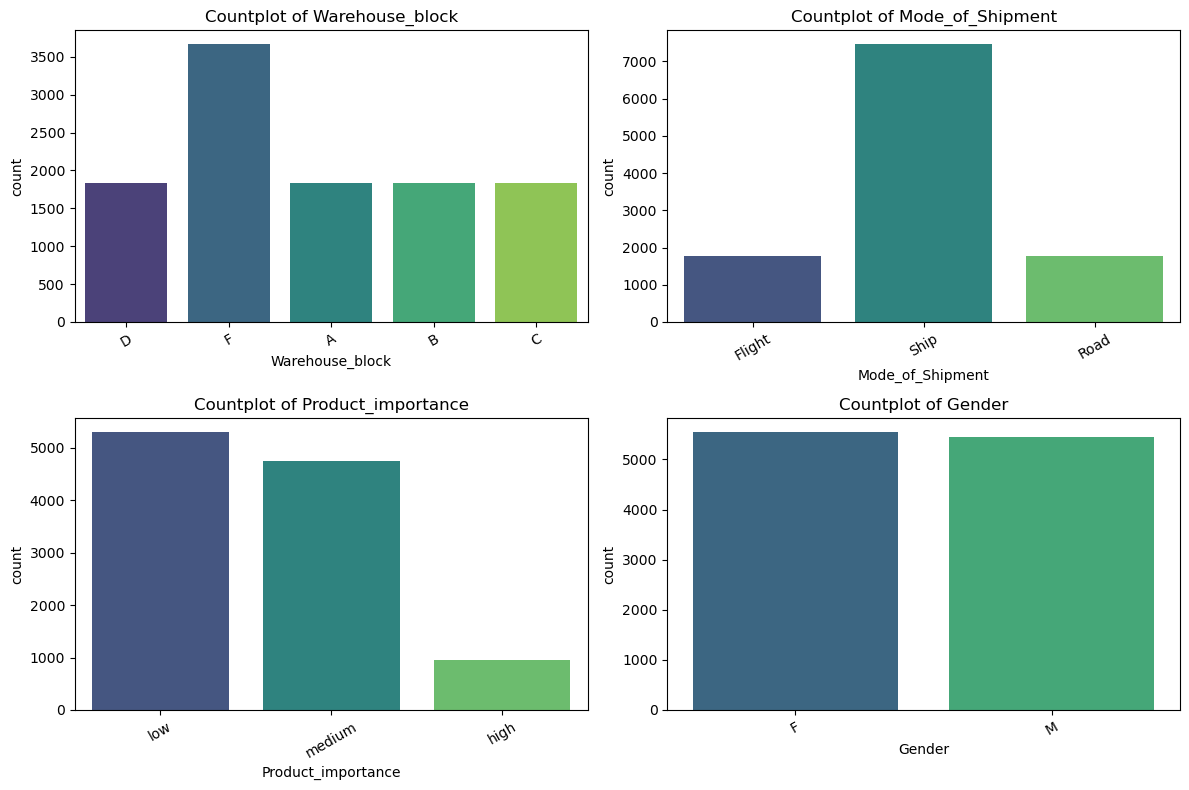

In [29]:
#FOR CATEGORICAL VALUE
import matplotlib.pyplot as plt
import seaborn as sns

cat_cols = ['Warehouse_block','Mode_of_Shipment','Product_importance','Gender']

# Countplots for categorical variables
plt.figure(figsize=(12,8))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(2,2,i)
    sns.countplot(x=df[col], palette="viridis")
    plt.title(f"Countplot of {col}")
    plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

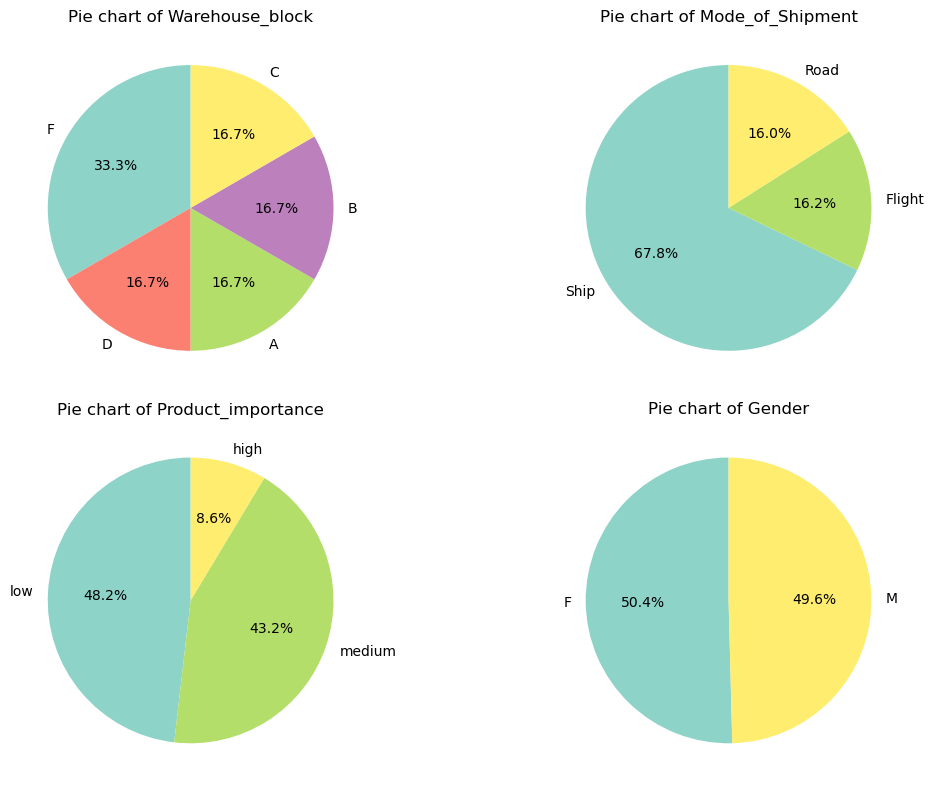

In [30]:
# Pie charts for categorical variables
plt.figure(figsize=(12,8))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(2,2,i)
    df[col].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, cmap="Set3")
    plt.title(f"Pie chart of {col}")
    plt.ylabel("")
plt.tight_layout()
plt.show()

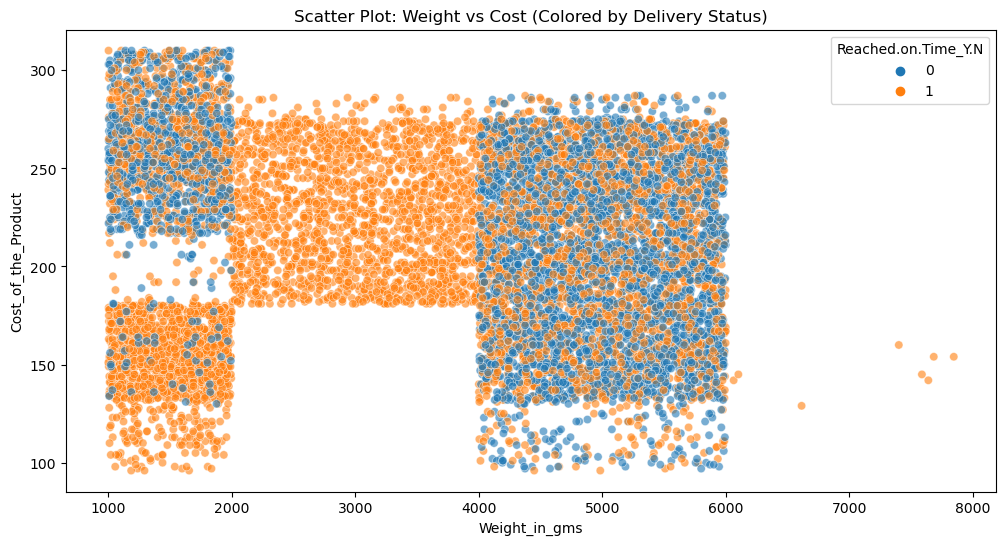

In [32]:
# Numeric vs Numeric → Scatter Plots
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.scatterplot(x='Weight_in_gms', y='Cost_of_the_Product',
                hue='Reached.on.Time_Y.N', data=df, alpha=0.6)
plt.title("Scatter Plot: Weight vs Cost (Colored by Delivery Status)")
plt.show()


C:\Users\Girija S.H\AppData\Local\Temp\ipykernel_3268\3510248932.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='Prior_purchases', y='Cost_of_the_Product', data=df, ci=None)


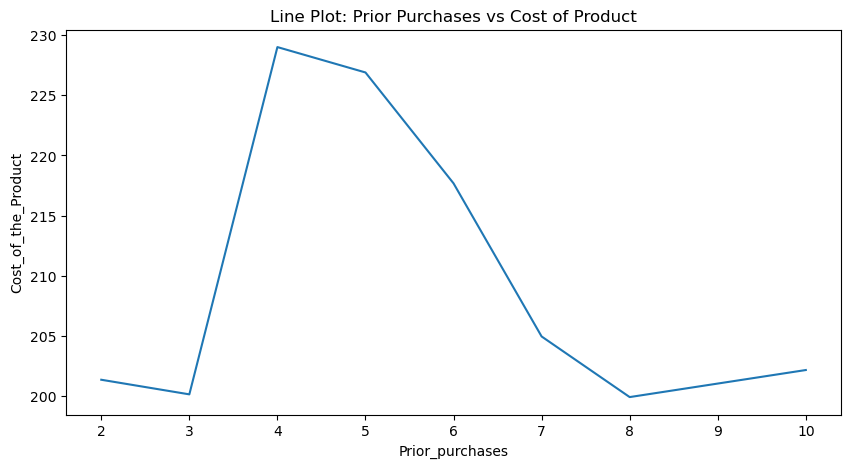

In [33]:
#Numeric vs Numeric → Line Plot
plt.figure(figsize=(10,5))
sns.lineplot(x='Prior_purchases', y='Cost_of_the_Product', data=df, ci=None)
plt.title("Line Plot: Prior Purchases vs Cost of Product")
plt.show()


C:\Users\Girija S.H\AppData\Local\Temp\ipykernel_3268\1339133155.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Product_importance', y='Cost_of_the_Product', data=df, estimator=np.mean, ci=None)


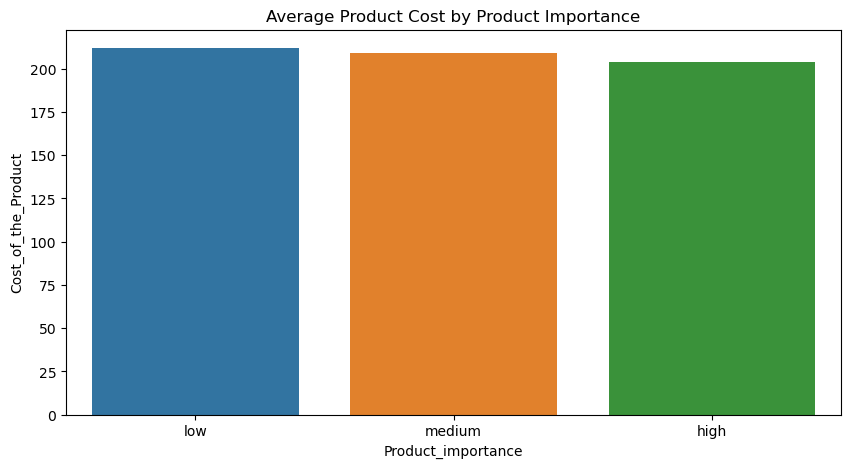

In [34]:
#Categorical vs Numeric → Bar Plots
plt.figure(figsize=(10,5))
sns.barplot(x='Product_importance', y='Cost_of_the_Product', data=df, estimator=np.mean, ci=None)
plt.title("Average Product Cost by Product Importance")
plt.show()


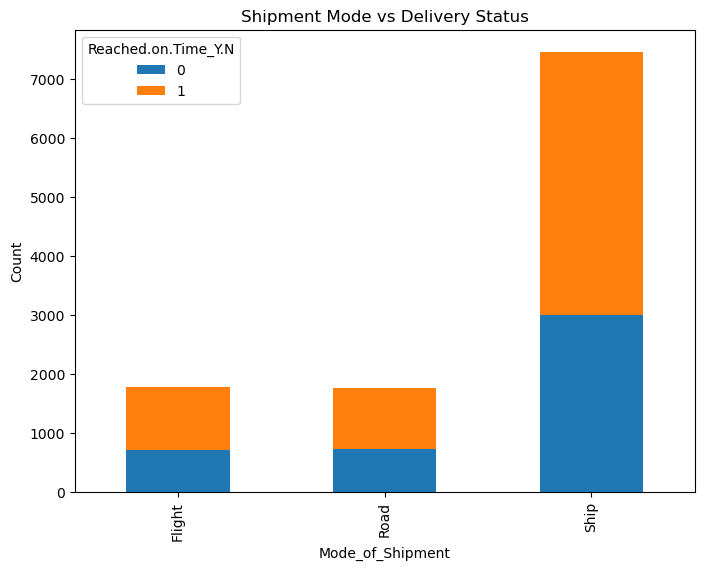

In [35]:
#Categorical vs Categorical → Crosstab / Stacked Bar
pd.crosstab(df['Mode_of_Shipment'], df['Reached.on.Time_Y.N']).plot(kind='bar', stacked=True, figsize=(8,6))
plt.title("Shipment Mode vs Delivery Status")
plt.ylabel("Count")
plt.show()


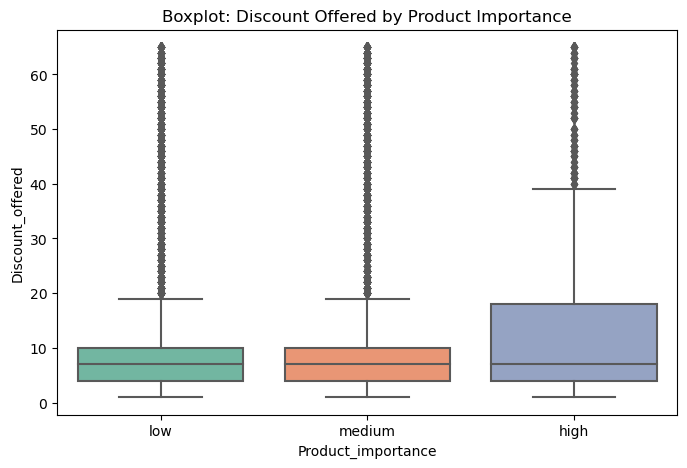

In [36]:
#Boxplot (Categorical vs Numeric)
plt.figure(figsize=(8,5))
sns.boxplot(x='Product_importance', y='Discount_offered', data=df, palette="Set2")
plt.title("Boxplot: Discount Offered by Product Importance")
plt.show()


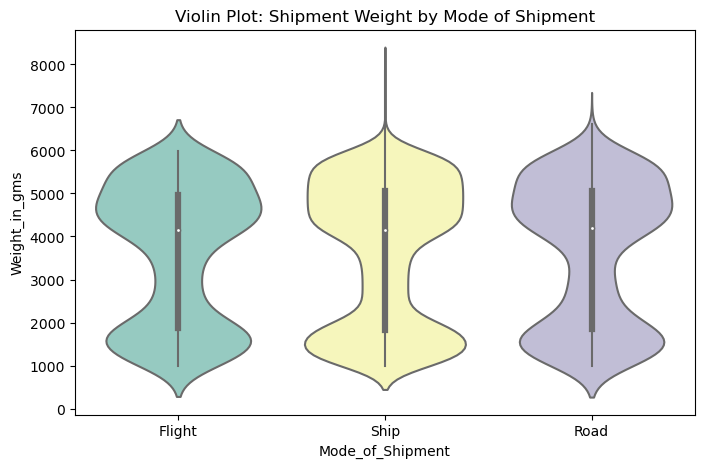

In [37]:
#Violin Plot (Categorical vs Numeric)
plt.figure(figsize=(8,5))
sns.violinplot(x='Mode_of_Shipment', y='Weight_in_gms', data=df, palette="Set3")
plt.title("Violin Plot: Shipment Weight by Mode of Shipment")
plt.show()


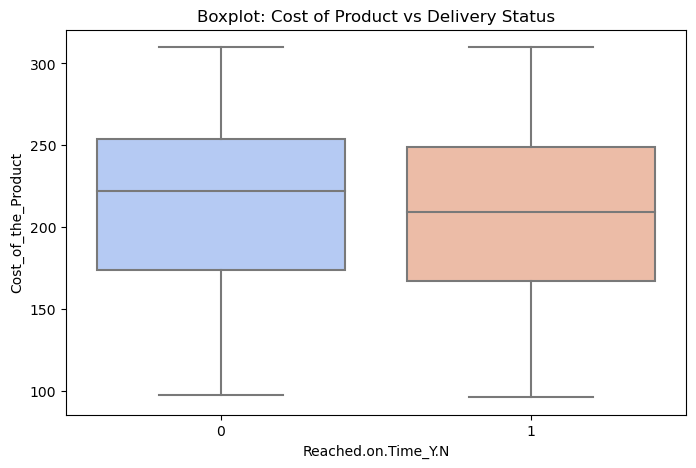

In [38]:
#Boxplot with Target (Numeric vs Target)
plt.figure(figsize=(8,5))
sns.boxplot(x='Reached.on.Time_Y.N', y='Cost_of_the_Product', data=df, palette="coolwarm")
plt.title("Boxplot: Cost of Product vs Delivery Status")
plt.show()


C:\Users\Girija S.H\AppData\Local\Temp\ipykernel_3268\3954164994.py:8: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")


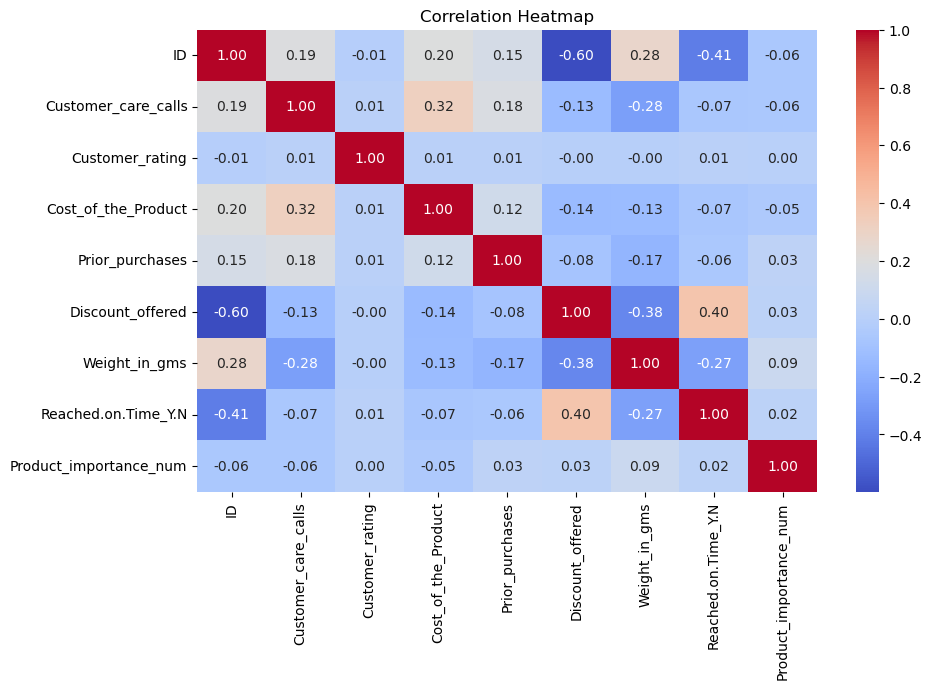

In [39]:

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


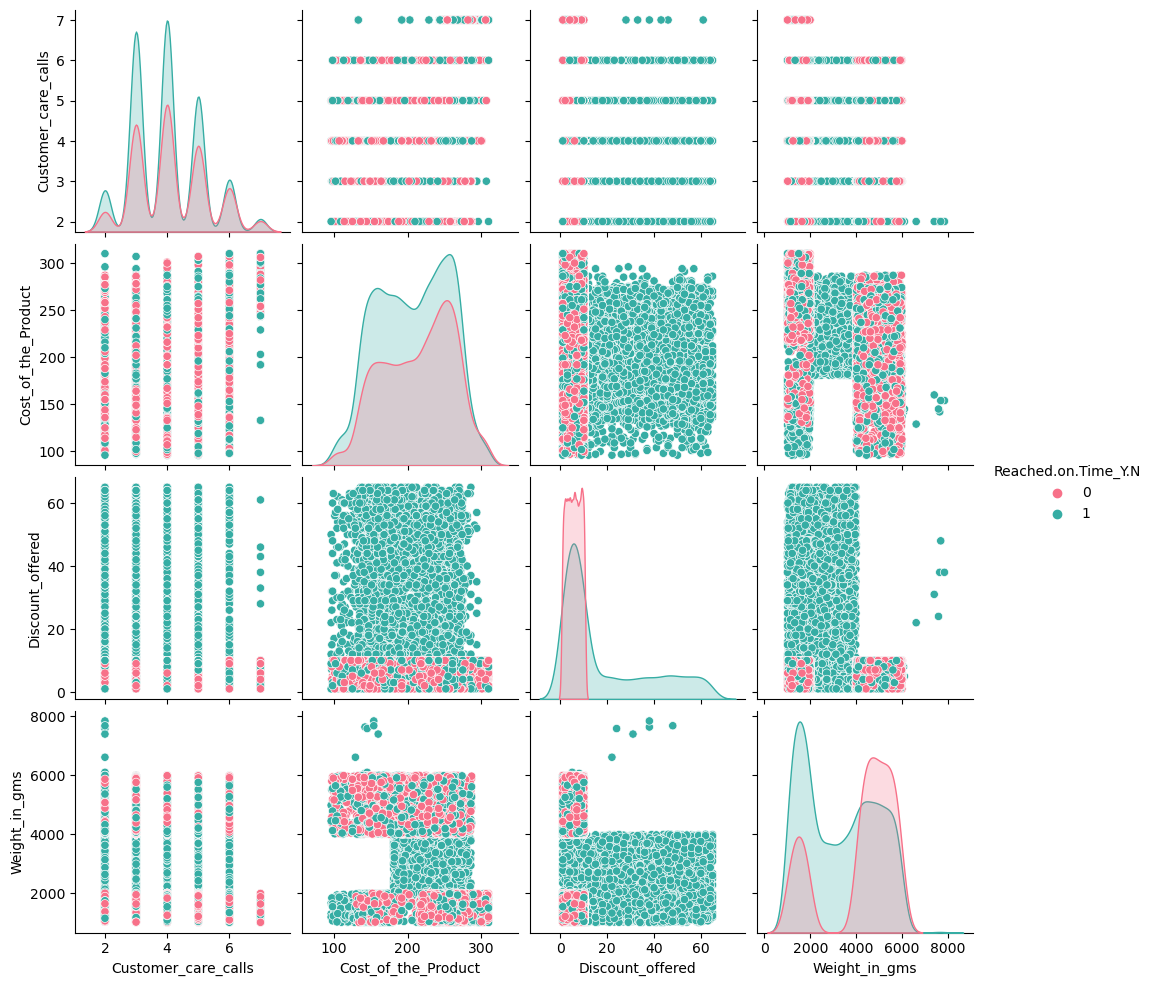

In [41]:
#Pairplot (Multiple Numeric Features vs Target)
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ['Customer_care_calls','Cost_of_the_Product',
            'Discount_offered','Weight_in_gms']

sns.pairplot(df[num_cols + ['Reached.on.Time_Y.N']], 
             hue='Reached.on.Time_Y.N', diag_kind='kde', palette="husl")
plt.show()


In [42]:
#3D Scatter Plot (Optional – for better visualization)
import plotly.express as px

fig = px.scatter_3d(df, 
                    x='Cost_of_the_Product', 
                    y='Weight_in_gms', 
                    z='Discount_offered',
                    color='Reached.on.Time_Y.N',
                    title="3D Scatter: Cost vs Weight vs Discount (Delivery Status)")
fig.show()


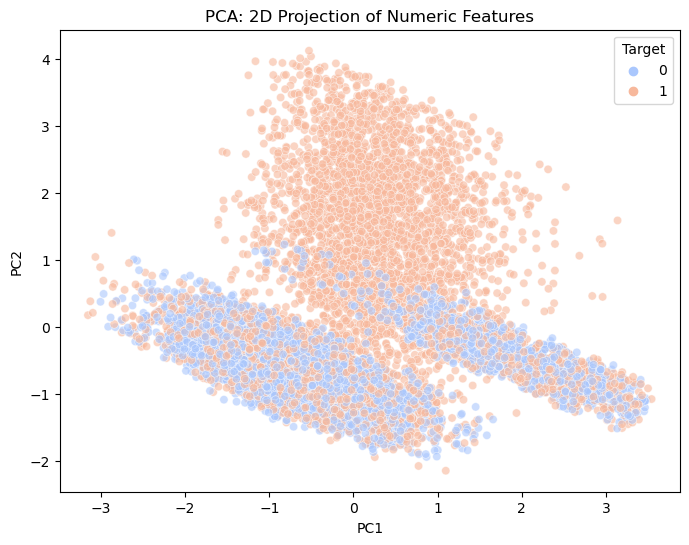

Explained Variance Ratio: [0.37505068 0.33637644]


In [43]:
#Principal Component Analysis (PCA) – Dimensionality Reduction
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Select numeric features
X = df[num_cols]

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA (2 components)
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)

# Create new dataframe
pca_df = pd.DataFrame(pca_data, columns=['PC1','PC2'])
pca_df['Target'] = df['Reached.on.Time_Y.N']

# Plot PCA
plt.figure(figsize=(8,6))
sns.scatterplot(x='PC1', y='PC2', hue='Target', data=pca_df, palette="coolwarm", alpha=0.6)
plt.title("PCA: 2D Projection of Numeric Features")
plt.show()

# Explained variance
print("Explained Variance Ratio:", pca.explained_variance_ratio_)


#FEATURE EXTRACTION 


In [44]:
!pip install lightgbm

Defaulting to user installation because normal site-packages is not writeable

In [45]:
# =========================
# 📦 Import Required Libraries
# =========================
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


In [46]:
# =========================
# STEP 1: LOAD DATA
# =========================
path = r"C:\Users\Girija S.H\.cache\kagglehub\datasets\prachi13\customer-analytics\versions\1"
train_path = os.path.join(path, "Train.csv")

df = pd.read_csv(train_path)
print("✅ Dataset loaded successfully!")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head(), "\n")


✅ Dataset loaded successfully!
Shape: (10999, 12)
Columns: ['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases', 'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms', 'Reached.on.Time_Y.N']
   ID Warehouse_block Mode_of_Shipment  Customer_care_calls  Customer_rating  \
0   1               D           Flight                    4                2   
1   2               F           Flight                    4                5   
2   3               A           Flight                    2                2   
3   4               B           Flight                    3                3   
4   5               C           Flight                    2                2   

   Cost_of_the_Product  Prior_purchases Product_importance Gender  \
0                  177                3                low      F   
1                  216                2                low      M   
2                  183         

In [47]:
# =========================
# STEP 2: MISSING VALUE HANDLING
# =========================
df_processed = df.copy()
numerical_cols = df_processed.select_dtypes(include=['int64', 'float64']).columns.tolist()

if df_processed.isnull().sum().sum() > 0:
    print('Applying Median Imputation...')
    imputer = SimpleImputer(strategy='median')
    df_processed[numerical_cols] = imputer.fit_transform(df_processed[numerical_cols])
else:
    print('✅ No missing values found.')

print(f"Missing values after check: {df_processed.isnull().sum().sum()}")


✅ No missing values found.
Missing values after check: 0


In [48]:
# =========================
# STEP 3: FEATURE ENGINEERING
# =========================
print('\nCreating Derived Features...')
df_processed['Weight_per_Cost'] = df_processed['Weight_in_gms'] / (df_processed['Cost_of_the_Product'] + 1)
df_processed['Discount_Value'] = df_processed['Cost_of_the_Product'] * (df_processed['Discount_offered'] / 100)
df_processed['High_Priority'] = (df_processed['Product_importance'] == 'high').astype(int)
df_processed['High_Rating'] = (df_processed['Customer_rating'] >= 4).astype(int)
print('✅ Created new features successfully!')



Creating Derived Features...
✅ Created new features successfully!


In [49]:
# =========================
# STEP 4: ENCODING CATEGORICAL VARIABLES
# =========================
print('\nEncoding categorical features...')
le = LabelEncoder()
df_processed['Gender_Encoded'] = le.fit_transform(df_processed['Gender'])

df_encoded = pd.get_dummies(
    df_processed,
    columns=['Warehouse_block', 'Mode_of_Shipment', 'Product_importance'],
    drop_first=True
)

# Drop unnecessary columns
cols_to_drop = ['ID', 'Gender']
df_encoded = df_encoded.drop(columns=cols_to_drop, errors='ignore')

target_col = 'Reached.on.Time_Y.N'
X = df_encoded.drop(columns=[target_col])
y = df_encoded[target_col]

print(f"✅ Encoding complete | Final shape: {df_encoded.shape}")



Encoding categorical features...
✅ Encoding complete | Final shape: (10999, 20)


In [50]:
# =========================
# STEP 4: ENCODING CATEGORICAL VARIABLES
# =========================
print('\nEncoding categorical features...')
le = LabelEncoder()
df_processed['Gender_Encoded'] = le.fit_transform(df_processed['Gender'])

df_encoded = pd.get_dummies(
    df_processed,
    columns=['Warehouse_block', 'Mode_of_Shipment', 'Product_importance'],
    drop_first=True
)

# Drop unnecessary columns
cols_to_drop = ['ID', 'Gender']
df_encoded = df_encoded.drop(columns=cols_to_drop, errors='ignore')

target_col = 'Reached.on.Time_Y.N'
X = df_encoded.drop(columns=[target_col])
y = df_encoded[target_col]

print(f"✅ Encoding complete | Final shape: {df_encoded.shape}")



Encoding categorical features...
✅ Encoding complete | Final shape: (10999, 20)


In [51]:
# =========================
# STEP 5: TRAIN-TEST SPLIT + SCALING
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Train-Test Split & Feature Scaling Done.")
print(f"Train shape: {X_train_scaled.shape}, Test shape: {X_test_scaled.shape}")


✅ Train-Test Split & Feature Scaling Done.
Train shape: (8799, 19), Test shape: (2200, 19)


In [52]:
# =========================
# STEP 6: MODEL INITIALIZATION
# =========================
models = {
    'Logistic Regression': LogisticRegression(max_iter=500),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'AdaBoost': AdaBoostClassifier(),
    'SVM': SVC(),
    'Naive Bayes': GaussianNB(),
    'KNN': KNeighborsClassifier(),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    'LightGBM': LGBMClassifier()
}


In [53]:
# =========================
# STEP 7: DEFINE HYPERPARAMETER GRIDS
# =========================
param_grids = {
    'Logistic Regression': {'C': [0.1, 1, 10]},
    'Decision Tree': {'max_depth': [5, 10, None]},
    'Random Forest': {'n_estimators': [100, 200], 'max_depth': [10, 20, None]},
    'Gradient Boosting': {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1]},
    'AdaBoost': {'n_estimators': [50, 100], 'learning_rate': [0.5, 1.0]},
    'SVM': {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']},
    'Naive Bayes': {},
    'KNN': {'n_neighbors': [3, 5, 7]},
    'XGBoost': {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1]},
    'LightGBM': {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1]}
}


In [59]:
# =========================
# STEP 8: MODEL TRAINING + HYPERPARAMETER TUNING
# =========================
results = []

print("\n🔍 Starting Model Training & Hyperparameter Tuning...")
print("="*60)

for name, model in models.items():
    print(f"\n🚀 Training {name}...")
    grid = GridSearchCV(model, param_grids[name], cv=3, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train_scaled, y_train)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        'Model': name,
        'Best Params': grid.best_params_,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

results_df = pd.DataFrame(results)



🔍 Starting Model Training & Hyperparameter Tuning...

🚀 Training Logistic Regression...

🚀 Training Decision Tree...

🚀 Training Random Forest...

🚀 Training Gradient Boosting...

🚀 Training AdaBoost...

🚀 Training SVM...

🚀 Training Naive Bayes...

🚀 Training KNN...

🚀 Training XGBoost...


C:\Users\Girija S.H\AppData\Roaming\Python\Python311\site-packages\xgboost\training.py:183: UserWarning:

[15:15:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.





🚀 Training LightGBM...
[LightGBM] [Info] Number of positive: 5250, number of negative: 3549
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000869 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1102
[LightGBM] [Info] Number of data points in the train set: 8799, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.596659 -> initscore=0.391562
[LightGBM] [Info] Start training from score 0.391562


C:\Users\Girija S.H\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



"""We cleaned categorical noise by standardizing string columns — converting them to lowercase, 
removing extra spaces, and unifying common category variations. This ensures consistency so values 
like "High", "high ", and "high importance" are treated as one. It prevents duplicate categories and 
improves the quality of features for ML models"""

In [60]:
# =========================
# STEP 9: RESULTS SUMMARY
# =========================
print("\n🏆 Model Performance Summary:")
print("="*60)
print(results_df.sort_values(by='Accuracy', ascending=False))



🏆 Model Performance Summary:
                 Model                                   Best Params  \
1        Decision Tree                              {'max_depth': 5}   
3    Gradient Boosting  {'learning_rate': 0.05, 'n_estimators': 100}   
4             AdaBoost   {'learning_rate': 0.5, 'n_estimators': 100}   
2        Random Forest        {'max_depth': 10, 'n_estimators': 100}   
8              XGBoost  {'learning_rate': 0.05, 'n_estimators': 100}   
9             LightGBM  {'learning_rate': 0.05, 'n_estimators': 100}   
5                  SVM                 {'C': 10, 'kernel': 'linear'}   
6          Naive Bayes                                            {}   
0  Logistic Regression                                      {'C': 1}   
7                  KNN                            {'n_neighbors': 3}   

   Accuracy  Precision    Recall  F1-Score  
1  0.683182   0.966667  0.485910  0.646731  
3  0.680909   0.934566  0.500381  0.651786  
4  0.676818   0.797431  0.614623  0.694194

In [61]:
# =========================
# STEP 10: BEST MODEL EVALUATION
# =========================
best_model_name = results_df.sort_values(by='Accuracy', ascending=False).iloc[0]['Model']
print(f"\n✅ Best Performing Model: {best_model_name}")

best_params = results_df[results_df['Model'] == best_model_name]['Best Params'].values[0]
best_estimator = GridSearchCV(models[best_model_name], param_grids[best_model_name], cv=3)
best_estimator.fit(X_train_scaled, y_train)
y_pred_best = best_estimator.best_estimator_.predict(X_test_scaled)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))



✅ Best Performing Model: Decision Tree

Confusion Matrix:
[[865  22]
 [675 638]]

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.98      0.71       887
           1       0.97      0.49      0.65      1313

    accuracy                           0.68      2200
   macro avg       0.76      0.73      0.68      2200
weighted avg       0.80      0.68      0.67      2200



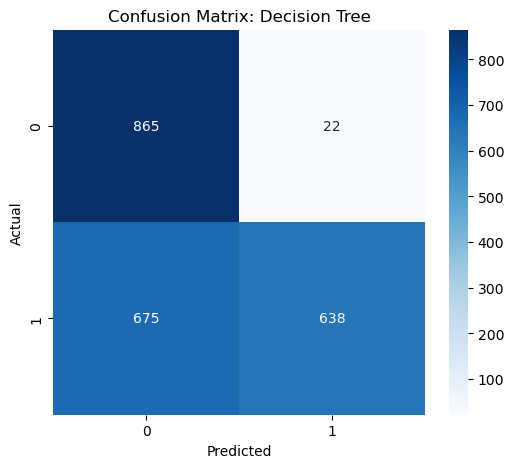


Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.98      0.71       887
           1       0.97      0.49      0.65      1313

    accuracy                           0.68      2200
   macro avg       0.76      0.73      0.68      2200
weighted avg       0.80      0.68      0.67      2200



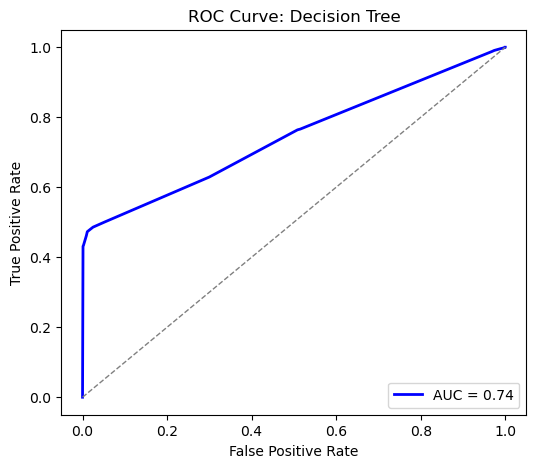

In [63]:
# =========================
# STEP 11: BEST MODEL EVALUATION VISUALIZATION
# =========================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

# Predict using best model
y_pred_best = best_estimator.best_estimator_.predict(X_test_scaled)
y_proba_best = best_estimator.best_estimator_.predict_proba(X_test_scaled)[:, 1] if hasattr(best_estimator.best_estimator_, "predict_proba") else best_estimator.best_estimator_.decision_function(X_test_scaled)

# 1️⃣ Confusion Matrix
plt.figure(figsize=(6,5))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix: {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 2️⃣ Classification Report (already printed)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

# 3️⃣ ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba_best)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], color='gray', lw=1, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve: {best_model_name}")
plt.legend(loc="lower right")
plt.show()


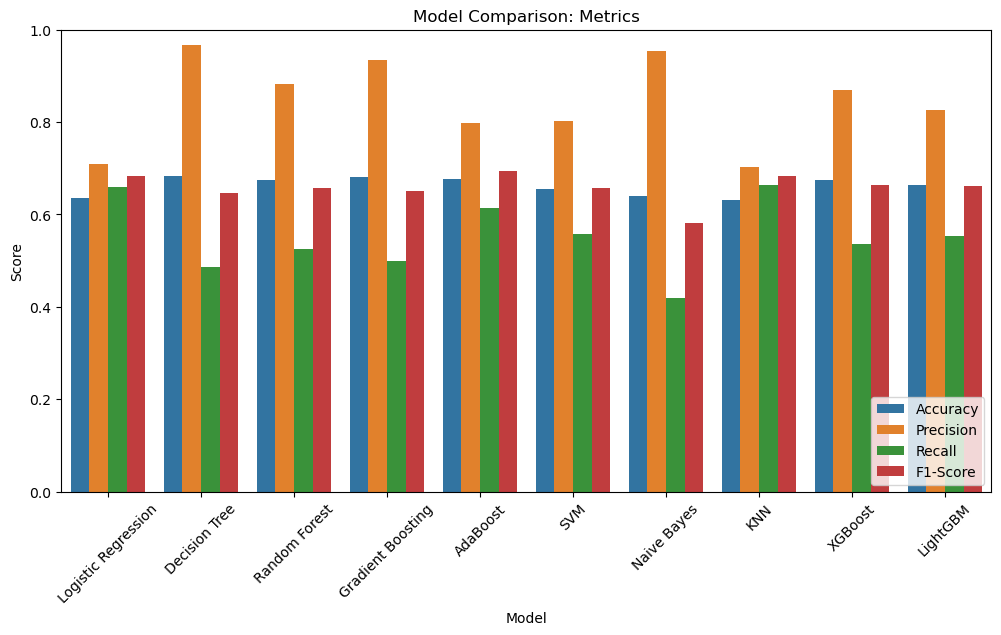

C:\Users\Girija S.H\AppData\Roaming\Python\Python311\site-packages\xgboost\training.py:183: UserWarning:

[15:38:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.




[LightGBM] [Info] Number of positive: 5250, number of negative: 3549
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002537 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1102
[LightGBM] [Info] Number of data points in the train set: 8799, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.596659 -> initscore=0.391562
[LightGBM] [Info] Start training from score 0.391562


C:\Users\Girija S.H\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names

C:\Users\Girija S.H\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



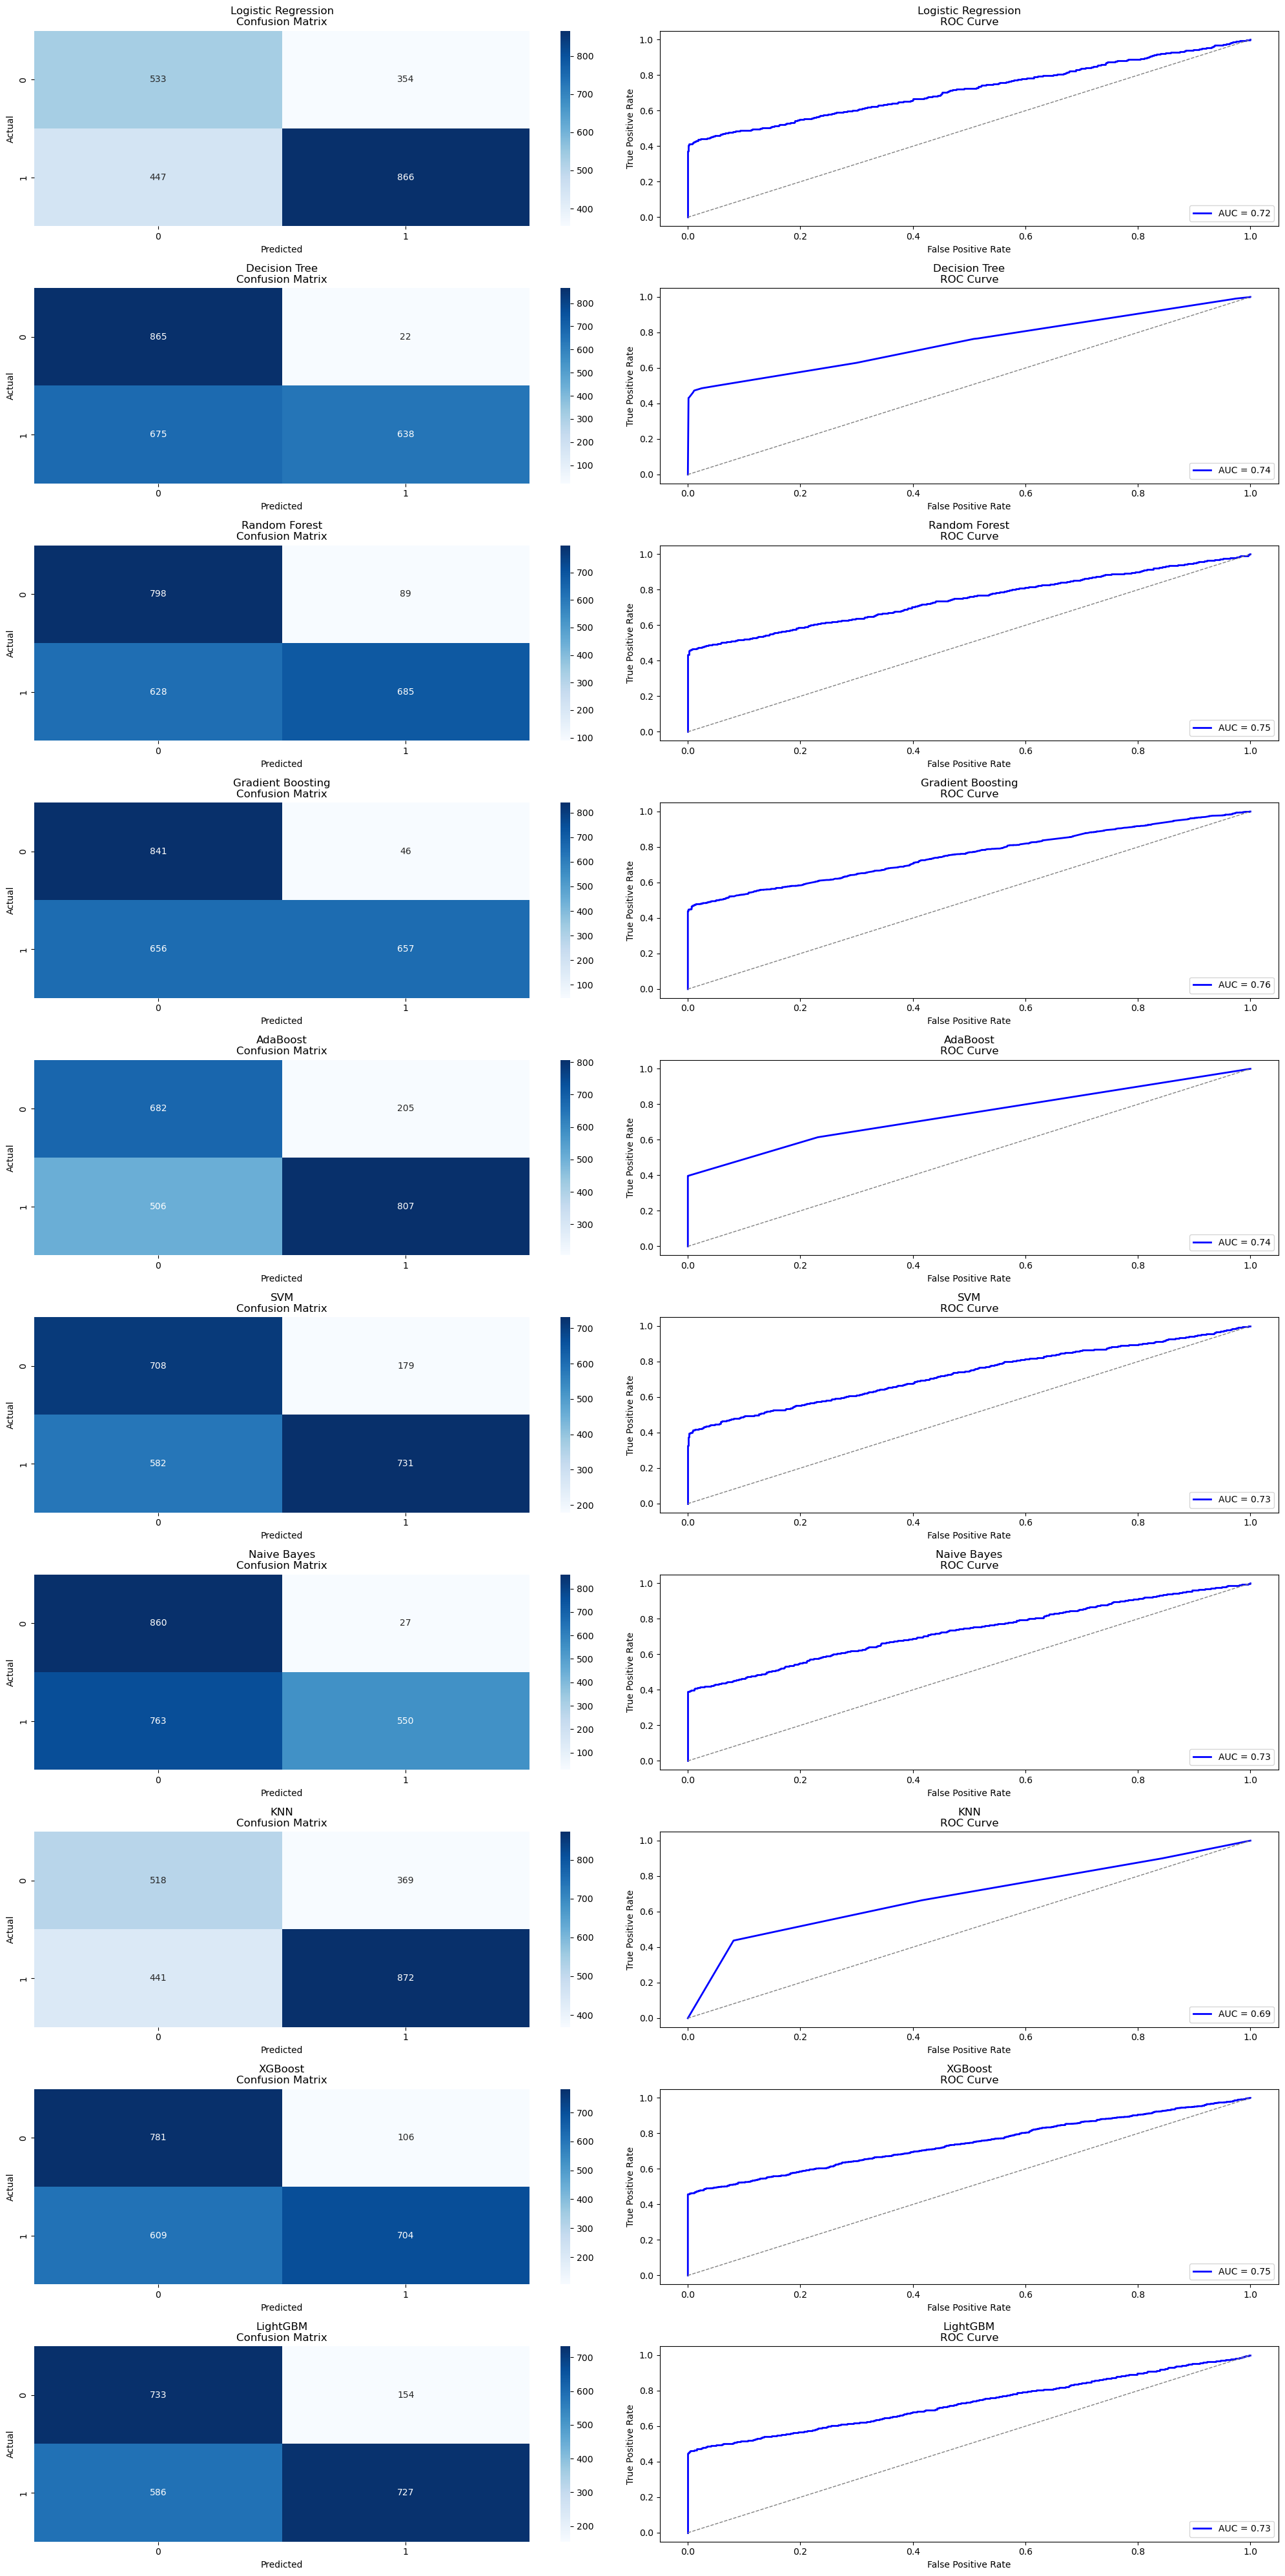

In [64]:
# =========================
# ALL MODELS VISUALIZATION
# =========================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

# 1️⃣ Bar chart for metrics
metrics_plot = results_df.melt(
    id_vars='Model', 
    value_vars=['Accuracy','Precision','Recall','F1-Score'],
    var_name='Metric', 
    value_name='Score'
)

plt.figure(figsize=(12,6))
sns.barplot(x='Model', y='Score', hue='Metric', data=metrics_plot)
plt.title("Model Comparison: Metrics")
plt.xticks(rotation=45)
plt.ylim(0,1)
plt.legend(loc='lower right')
plt.show()

# 2️⃣ Confusion Matrices + ROC Curves for all models
num_models = len(results_df)
plt.figure(figsize=(20, 4*num_models))

for i, row in enumerate(results_df.itertuples(), 1):
    model_name = row.Model
    
    # Refit GridSearchCV if needed
    model = models[model_name]
    grid = GridSearchCV(model, param_grids[model_name], cv=3, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train_scaled, y_train)
    best_model = grid.best_estimator_
    
    y_pred = best_model.predict(X_test_scaled)
    y_proba = best_model.predict_proba(X_test_scaled)[:,1] if hasattr(best_model, "predict_proba") else best_model.decision_function(X_test_scaled)
    
    # Confusion Matrix
    plt.subplot(num_models, 2, 2*i-1)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{model_name}\nConfusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    
    # ROC Curve
    plt.subplot(num_models, 2, 2*i)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color='blue', lw=2, label=f"AUC = {roc_auc:.2f}")
    plt.plot([0,1], [0,1], color='gray', lw=1, linestyle='--')
    plt.title(f"{model_name}\nROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc='lower right')

plt.tight_layout()
plt.show()
